In [48]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from temperature_model import correct_viscosity, laminar_pressure_loss

# Add src path
sys.path.append(os.path.abspath("../src"))

In [49]:
surface_viscosity = 35
T_surface = 25
activation_energy = 25000

temperatures = np.linspace(25, 180, 60)

viscosities = [
    correct_viscosity(surface_viscosity, T_surface, T, activation_energy)
    for T in temperatures
]

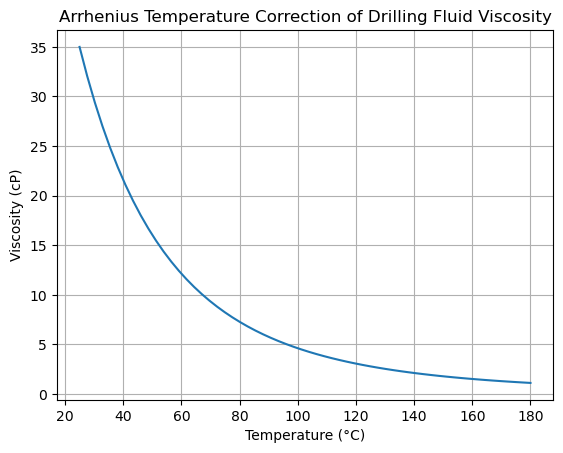

In [50]:
plt.figure()
plt.plot(temperatures, viscosities)
plt.xlabel("Temperature (°C)")
plt.ylabel("Viscosity (cP)")
plt.title("Arrhenius Temperature Correction of Drilling Fluid Viscosity")
plt.grid(True)
plt.savefig("../results/viscosity_vs_temperature.png", dpi=300)
plt.show()

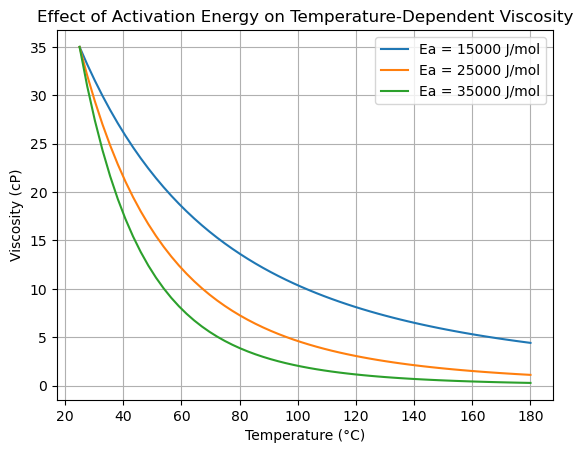

In [51]:
activation_energies = [15000, 25000, 35000]  # J/mol example range

plt.figure()

for Ea in activation_energies:
    viscosities = [
        correct_viscosity(surface_viscosity, T_surface, T, Ea)
        for T in temperatures
    ]
    plt.plot(temperatures, viscosities, label=f"Ea = {Ea} J/mol")

plt.xlabel("Temperature (°C)")
plt.ylabel("Viscosity (cP)")
plt.title("Effect of Activation Energy on Temperature-Dependent Viscosity")
plt.legend()
plt.grid(True)
plt.savefig("../results/activation_energy_sensitivity.png", dpi=300)
plt.show()


In [52]:
pressure_surface = []
pressure_corrected = []

flow_rate = 0.02        # m3/s (example)
pipe_length = 1000      # m
pipe_diameter = 0.1     # m

for T in temperatures:
    visc = correct_viscosity(surface_viscosity, T_surface, T, activation_energy)
    

    p_corr = laminar_pressure_loss(visc, flow_rate, pipe_length, pipe_diameter)
    p_surf = laminar_pressure_loss(surface_viscosity, flow_rate, pipe_length, pipe_diameter)



    
    pressure_corrected.append(p_corr)
    pressure_surface.append(p_surf)

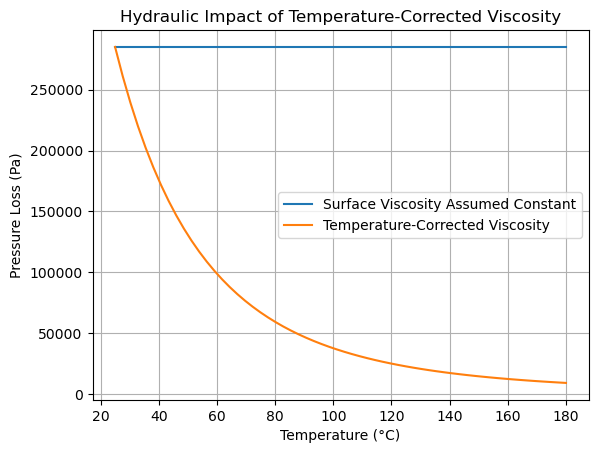

In [54]:
plt.figure()
plt.plot(temperatures, pressure_surface, label="Surface Viscosity Assumed Constant")
plt.plot(temperatures, pressure_corrected, label="Temperature-Corrected Viscosity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure Loss (Pa)")
plt.title("Hydraulic Impact of Temperature-Corrected Viscosity")
plt.legend()
plt.grid(True)
plt.savefig("../results/hydraulic_temperature_impact.png", dpi=300)
plt.show()


## Simulation Dataset Analysis

Load results generated by the batch simulation script and visualize temperature–viscosity behavior.

In [1]:
import pandas as pd

df = pd.read_csv("../results/temperature_viscosity_table.csv")

df.head()

,temperature_C,corrected_viscosity_cp
0,25.000000,35.000000
1,27.627119,32.048724
2,30.254237,29.391108
3,32.881356,26.993963
4,35.508475,24.828261


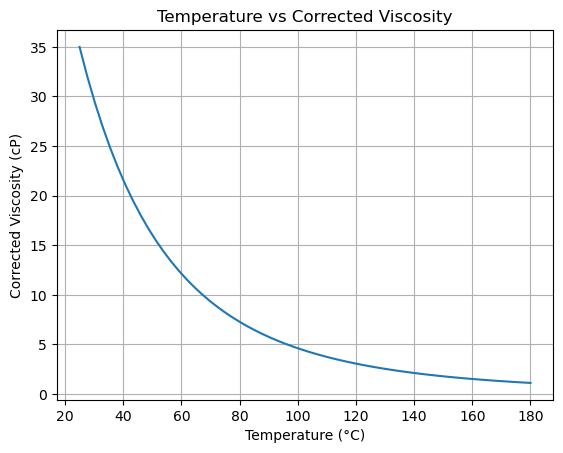

In [2]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["temperature_C"], df["corrected_viscosity_cp"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Corrected Viscosity (cP)")
plt.title("Temperature vs Corrected Viscosity")
plt.grid(True)

plt.show()

## Wellbore Viscosity Profile

In [3]:
df_well = pd.read_csv("../results/wellbore_viscosity_profile.csv")

df_well.head()

,depth_m,temperature_C,viscosity_cp
0,0.000000,25.000000,35.000000
1,61.224490,27.551020,32.129910
2,122.448980,30.102041,29.537665
3,183.673469,32.653061,27.192699
4,244.897959,35.204082,25.068185


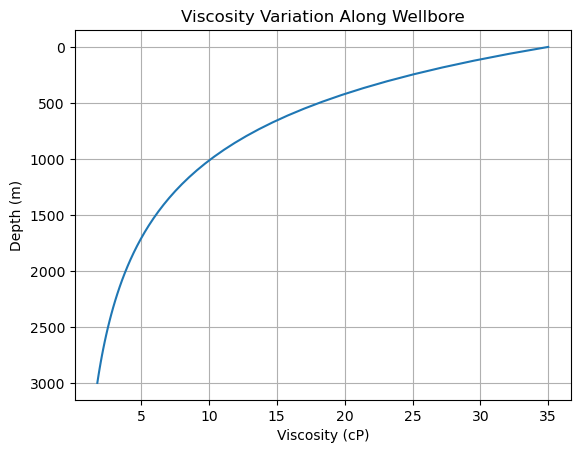

In [9]:
plt.figure()

plt.plot(df_well["viscosity_cp"], df_well["depth_m"])

plt.gca().invert_yaxis()

plt.xlabel("Viscosity (cP)")
plt.ylabel("Depth (m)")
plt.title("Viscosity Variation Along Wellbore")

plt.grid(True)
plt.savefig("../results/wellbore_viscosity_profile.png", dpi=300)
plt.show()

## Wellbore Pressure Loss Profile

In [1]:
df_pressure = pd.read_csv("../results/wellbore_hydraulics_profile.csv")

df_pressure.head()

<IPython.core.display.Javascript object>

,depth_m,temperature_C,viscosity_cp,segment_pressure_loss_pa,cumulative_pressure_loss_pa
0,0.000000,25.000000,35.000000,0.000000,0.000000
1,61.224490,27.551020,32.129910,16029.677404,16029.677404
2,122.448980,30.102041,29.537665,14736.400762,30766.078166
3,183.673469,32.653061,27.192699,13566.492859,44332.571025
4,244.897959,35.204082,25.068185,12506.568170,56839.139195


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

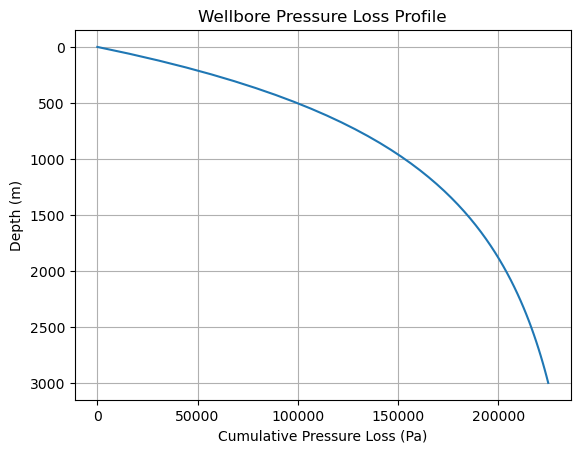

In [4]:
plt.figure()

plt.plot(df_pressure["cumulative_pressure_loss_pa"], df_pressure["depth_m"])

plt.gca().invert_yaxis()

plt.xlabel("Cumulative Pressure Loss (Pa)")
plt.ylabel("Depth (m)")
plt.title("Wellbore Pressure Loss Profile")

plt.grid(True)
plt.savefig("../results/wellbore_pressure_profile.png", dpi=300)
plt.show()